# 02. 탐색적 데이터 분석 (EDA)

## 목적
리뷰 메타데이터를 활용하여 유저 행동 패턴을 파악한다.

## 분석 순서
1. 라이브러리 & DB 연결
2. 데이터 로드 & 파생 컬럼 생성
3. 기본 통계 요약
4. 월별 긍정/부정 추이
5. 플레이타임 구간별 분석
6. 언어별 분포
7. 얼리액세스 vs 정식출시
8. Steam Deck 유저 분석
9. 환불 유저 분석
10. 리뷰 길이 × 긍정/부정 (언어별)
11. 유저 보유 게임 수 × 긍정률
12. 요일/시간대별 리뷰 작성 패턴
13. 부정 리뷰 중 추천 수 상위
14. 리뷰 수정 유저 분석
15. 플레이타임 0 유저 분석
16. 개발자 응답 리뷰 분석
17. DB 연결 종료

---
## 1. 라이브러리 & DB 연결

In [1]:
import sys
import os
import platform
import sqlite3
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

figures_dir = os.path.join('..', 'reports', 'figures')
os.makedirs(figures_dir, exist_ok=True)

sys.path.append('..')
from config import DB_PATH, EVENTS

db_path = os.path.join('..', DB_PATH)
conn = sqlite3.connect(db_path)

print(f"DB 연결 완료: {db_path}")
print(f"figures 저장 경로: {os.path.abspath(figures_dir)}")

DB 연결 완료: ../data/dave_diver.db
figures 저장 경로: /Users/home1/Documents/dave-diver-review-analysis/reports/figures


---
## 2. 데이터 로드 & 파생 컬럼 생성

이후 분석에서 공통으로 쓰는 파생 컬럼을 한 곳에서 만들어 둔다.
- `review_length` : 리뷰 텍스트 글자 수
- `review_date` : datetime 타입 변환
- `weekday` : 요일 (Monday ~ Sunday)
- `hour` : 리뷰 작성 시각 (UTC 기준 0~23)

In [2]:
df = pd.read_sql("SELECT * FROM reviews", conn)

df['review_length'] = df['review_text'].fillna('').apply(len)
df['review_date']   = pd.to_datetime(df['review_date'])
df['weekday']       = df['review_date'].dt.day_name()
df['hour']          = pd.to_datetime(df['timestamp_created'], unit='s').dt.hour

print(f"총 리뷰 수 : {len(df):,}건")
print(f"컬럼 수    : {df.shape[1]}개")
df.head(3)

총 리뷰 수 : 145,877건
컬럼 수    : 57개


,review_id,language,appid,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,hardware.vram_size,timestamp_dev_responded,developer_response,review_date,review_month,playtime_hours_forever,playtime_hours_at_review,review_length,weekday,hour
0,218669790,latam,1868140,Uno de los juegos más hermosos y cautivadores ...,1771469881,1771469881,1,0,0,0.5,...,NaN,NaN,NaN,2026-02-19,2026-02,25.3,24.9,246,Thursday,2
1,218667160,koreana,1868140,2시간만 하고 환불 할려고 했는데 정신 차리니까 16시간 째 하고 있는 게임,1771466551,1771466551,1,0,0,0.5,...,NaN,NaN,NaN,2026-02-19,2026-02,17.5,17.5,42,Thursday,2
2,218667034,english,1868140,Sweet! Chum!,1771466393,1771466393,1,0,0,0.5,...,NaN,NaN,NaN,2026-02-19,2026-02,6.3,6.2,12,Thursday,1


In [3]:
df.columns

Index(['review_id', 'language', 'appid', 'review_text', 'timestamp_created',
       'timestamp_updated', 'voted_up', 'votes_up', 'votes_funny',
       'weighted_vote_score', 'comment_count', 'steam_purchase',
       'received_for_free', 'refunded', 'written_during_early_access',
       'primarily_steam_deck', 'app_release_date', 'reactions',
       'csgo_disclaimer', 'steam_id', 'author.personaname',
       'author.persona_status', 'author.profile_url', 'num_games_owned',
       'num_reviews', 'playtime_forever', 'author.playtime_last_two_weeks',
       'playtime_at_review', 'last_played', 'author.avatar',
       'author.deck_playtime_at_review', 'hardware.manufacturer',
       'hardware.model', 'hardware.dx_video_card', 'hardware.dx_vendorid',
       'hardware.dx_deviceid', 'hardware.num_gpu', 'hardware.system_ram',
       'hardware.os', 'hardware.cpu_vendor', 'hardware.cpu_name',
       'hardware.gaming_device_type', 'hardware.dx_driver_version',
       'hardware.dx_driver_name', 'ha

---
## 3. 기본 통계 요약

전체 데이터셋의 규모와 핵심 지표를 한눈에 확인한다.

In [ ]:
total     = len(df)
positive  = df['voted_up'].sum()
negative  = total - positive
pos_rate  = df['voted_up'].mean() * 100
med_hours = df['playtime_hours_at_review'].median()
date_min  = df['review_date'].min().strftime('%Y-%m-%d')
date_max  = df['review_date'].max().strftime('%Y-%m-%d')

print(f"총 리뷰           : {total:,}건")
print(f"긍정              : {positive:,}건 ({pos_rate:.1f}%)")
print(f"부정              : {negative:,}건")
print(f"플레이타임 중앙값 : {med_hours:.1f}시간")
print(f"수집 기간         : {date_min} ~ {date_max}")

총 리뷰           : 145,877건
긍정              : 141,216건 (96.8%)
부정              : 4,661건
플레이타임 중앙값 : 18.6시간
수집 기간         : 2022-10-27 ~ 2026-02-19


---
## 4. 월별 긍정/부정 추이

월별 리뷰 수(막대)와 긍정률(선)을 이중 축으로 시각화한다.
config.py의 EVENTS 타임라인을 세로선으로 표시해 업데이트/출시 시점과 감성 변화의 연관성을 파악한다.

In [ ]:
monthly = pd.read_sql("""
    SELECT
        review_month,
        COUNT(*) as total_reviews,
        SUM(voted_up) as positive,
        ROUND(AVG(voted_up) * 100, 1) as positive_rate
    FROM reviews
    GROUP BY review_month
    ORDER BY review_month
""", conn)

monthly.head()

,review_month,total_reviews,positive,positive_rate
0,2022-10,707,684,96.7
1,2022-11,4376,4311,98.5
2,2022-12,1391,1365,98.1
3,2023-01,1151,1124,97.7
4,2023-02,615,608,98.9


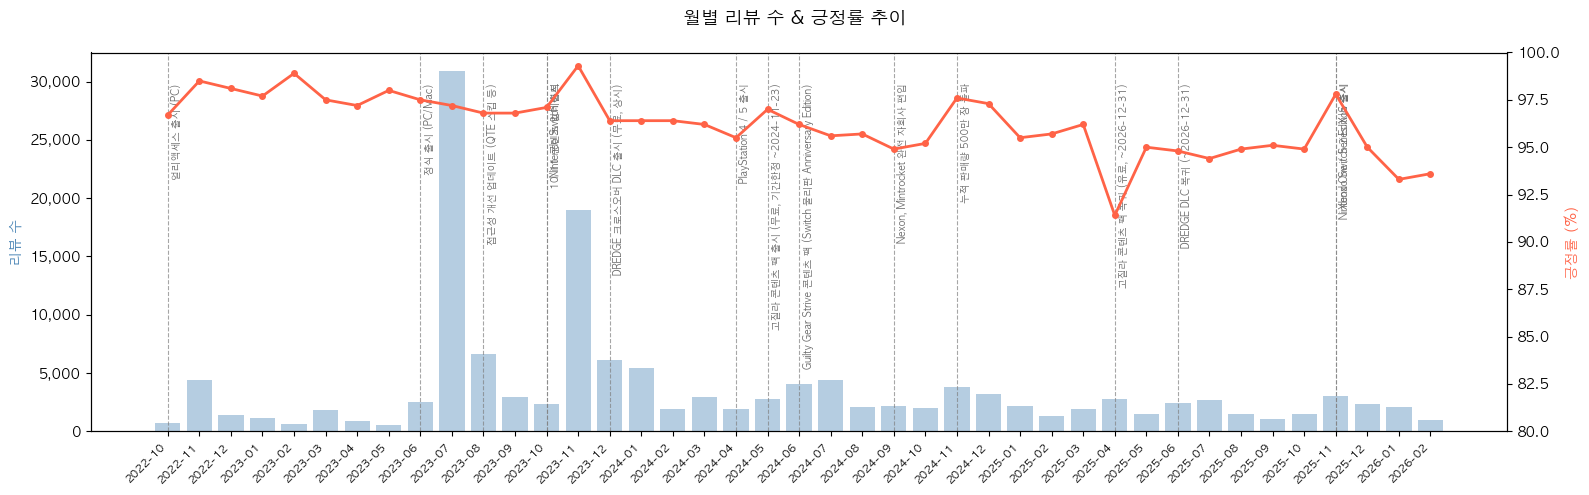

In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 5))

months = monthly['review_month'].tolist()
x = list(range(len(months)))

ax1.bar(x, monthly['total_reviews'], color='steelblue', alpha=0.4, label='리뷰 수')
ax1.set_ylabel('리뷰 수', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(months, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

ax2 = ax1.twinx()
ax2.plot(x, monthly['positive_rate'], color='tomato', marker='o', linewidth=2, markersize=4, label='긍정률(%)')
ax2.set_ylabel('긍정률 (%)', color='tomato')
ax2.set_ylim(80, 100)

for date, label in EVENTS.items():
    month = date[:7]
    if month in months:
        idx = months.index(month)
        ax1.axvline(x=idx, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        ax1.text(idx + 0.1, ax1.get_ylim()[1] * 0.92, label,
                 fontsize=7, rotation=90, va='top', ha='left', color='dimgray')

fig.suptitle('월별 리뷰 수 & 긍정률 추이', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(figures_dir, 'monthly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 플레이타임 구간별 분석

유저를 4개 구간(casual / regular / engaged / hardcore)으로 나눠
구간별 리뷰 수와 긍정률을 비교한다.
플레이타임이 짧은 구간의 긍정률이 낮다면 초반 이탈 원인을 의심해볼 수 있다.

In [ ]:
playtime = pd.read_sql("""
    SELECT
        CASE
            WHEN playtime_at_review < 120  THEN '1_casual (<2h)'
            WHEN playtime_at_review < 600  THEN '2_regular (2-10h)'
            WHEN playtime_at_review < 1800 THEN '3_engaged (10-30h)'
            WHEN playtime_at_review < 3000 THEN '4_engaged (30-50h)'
            ELSE '5_hardcore (50h+)'
        END as segment,
        COUNT(*) as count,
        ROUND(AVG(voted_up) * 100, 1) as positive_rate
    FROM reviews
    GROUP BY segment
    ORDER BY segment
""", conn)

playtime

,segment,count,positive_rate
0,1_casual (<2h),4948,87.8
1,2_regular (2-10h),40411,97.5
2,3_engaged (10-30h),51205,96.3
3,4_engaged (30-50h),28819,97.4
4,5_hardcore (50h+),20494,98.1


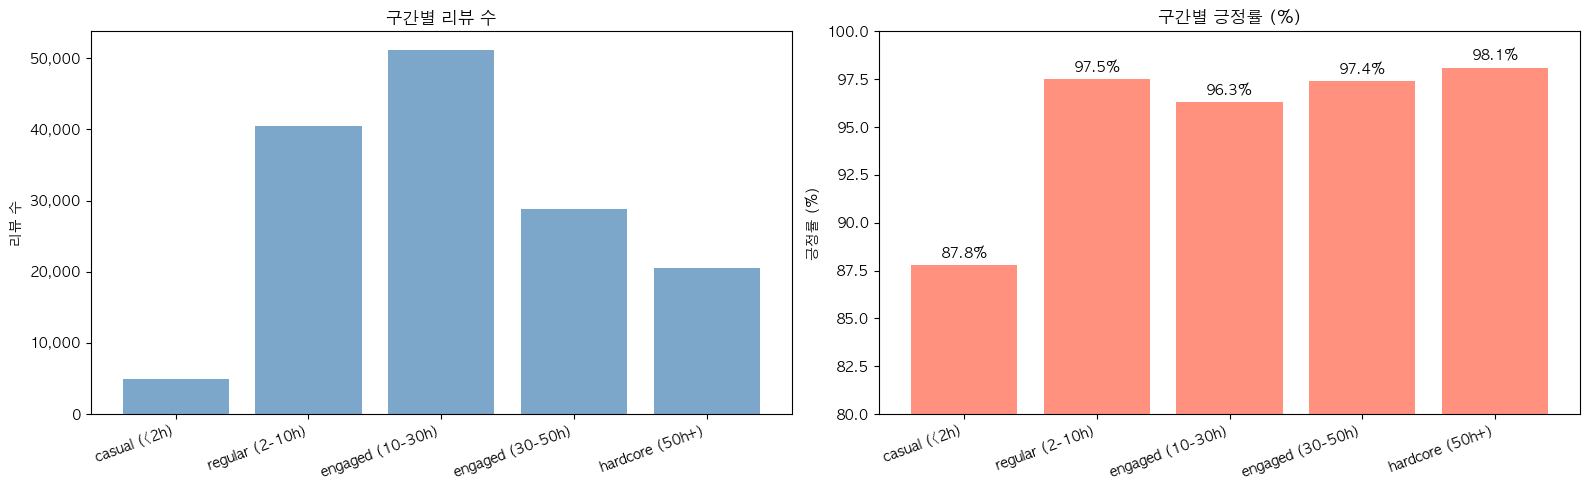

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

labels = [s.split('_', 1)[1] for s in playtime['segment']]

ax1.bar(labels, playtime['count'], color='steelblue', alpha=0.7)
ax1.set_title('구간별 리뷰 수')
ax1.set_ylabel('리뷰 수')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.set_xticklabels(labels, rotation=20, ha='right')

bars = ax2.bar(labels, playtime['positive_rate'], color='tomato', alpha=0.7)
ax2.set_title('구간별 긍정률 (%)')
ax2.set_ylabel('긍정률 (%)')
ax2.set_ylim(80, 100)
ax2.set_xticklabels(labels, rotation=20, ha='right')
for bar, val in zip(bars, playtime['positive_rate']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{val}%', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
plt.savefig(os.path.join(figures_dir, 'playtime_segment.png'), dpi=150, bbox_inches='tight')
plt.show()

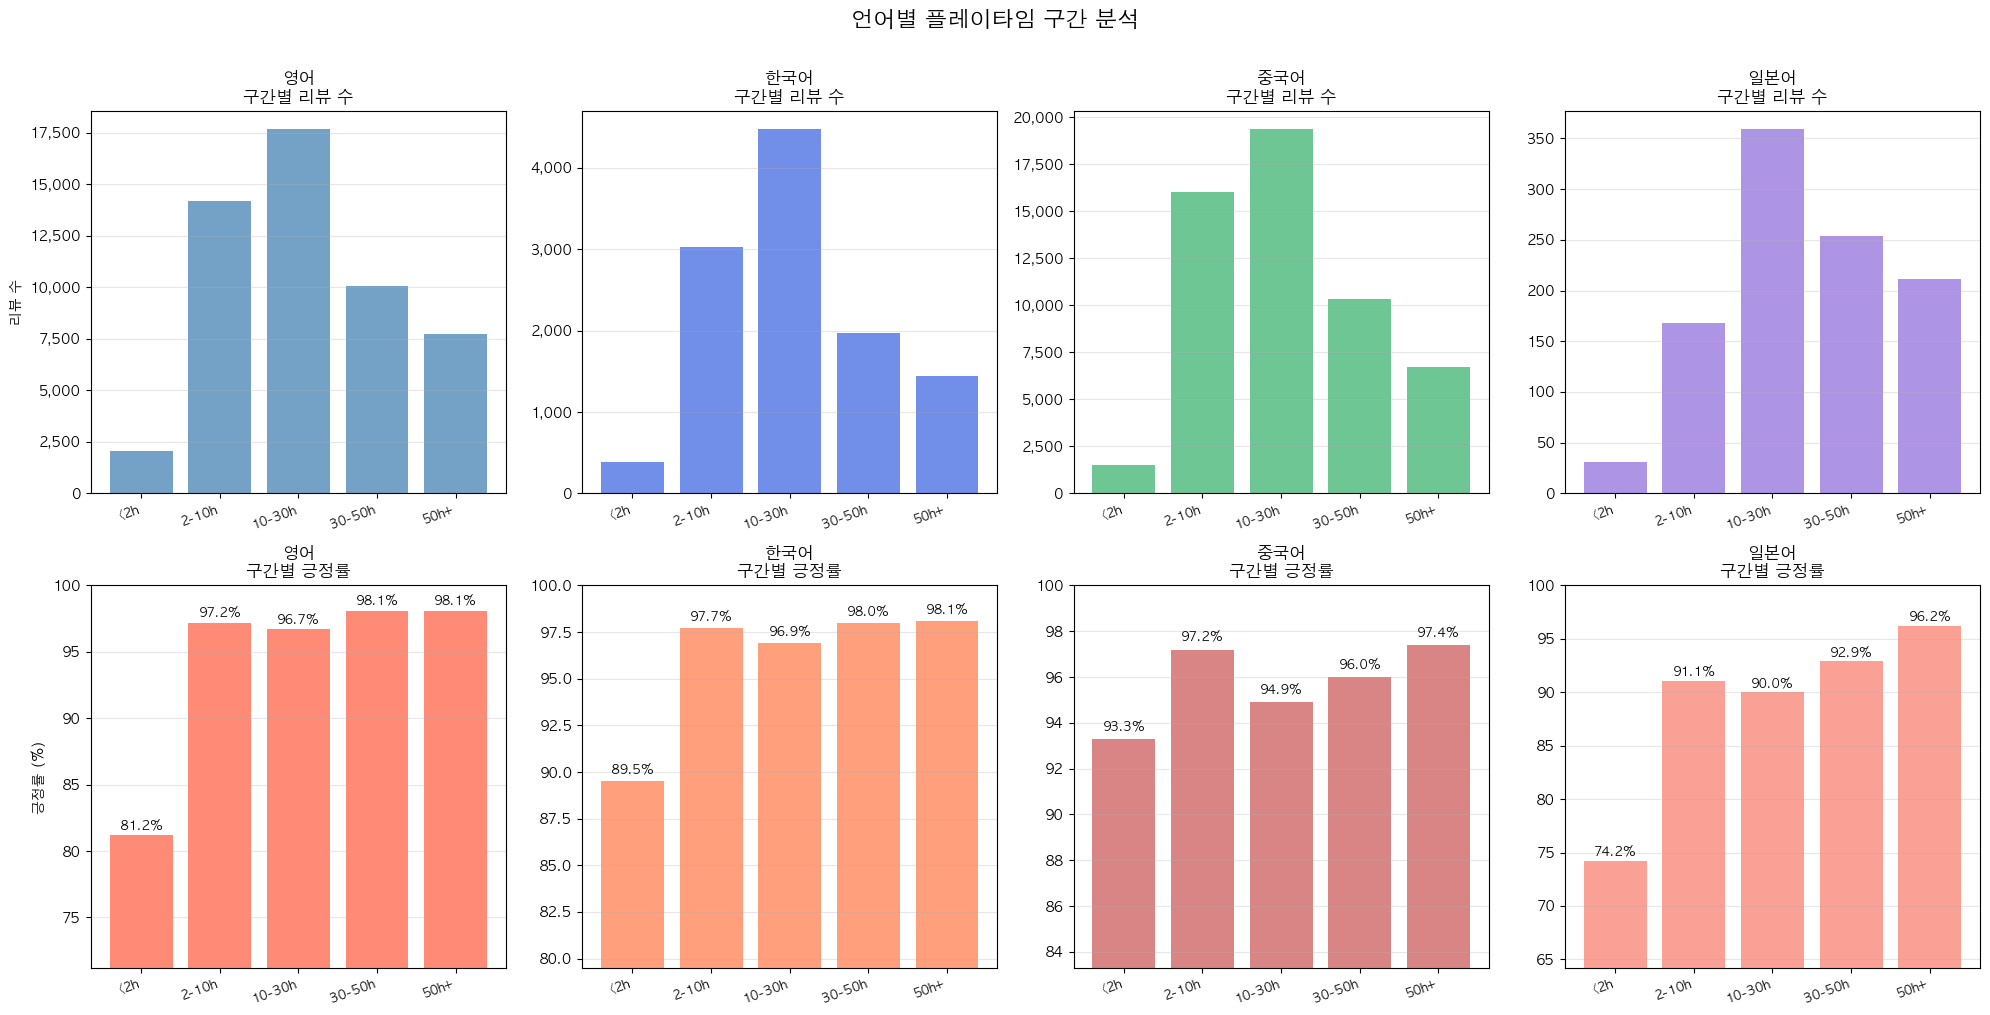

In [ ]:
# ── 언어 설정 ──────────────────────────────────────────────────
LANGUAGES = {
    'english':  '영어',
    'koreana':  '한국어',
    'schinese': '중국어',
    'japanese': '일본어',
}

# ── 플레이타임 구간 정의 ────────────────────────────────────────
bins_p   = [0, 120, 600, 1800, 3000, 999999]
labels_p = ['<2h', '2-10h', '10-30h', '30-50h', '50h+']

# ── 언어별 구간 집계 ────────────────────────────────────────────
lang_data = {}
for lang_code, lang_name in LANGUAGES.items():
    sub = df[df['language'] == lang_code].copy()
    sub['segment'] = pd.cut(sub['playtime_at_review'], bins=bins_p, labels=labels_p)
    agg = (
        sub.groupby('segment', observed=True)
           .agg(count=('voted_up', 'count'), positive_rate=('voted_up', 'mean'))
           .reset_index()
    )
    agg['positive_rate'] = (agg['positive_rate'] * 100).round(1)
    lang_data[lang_name] = agg

# ── 시각화: 2행 × 4열 ──────────────────────────────────────────
# 1행: 구간별 리뷰 수 / 2행: 구간별 긍정률
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('언어별 플레이타임 구간 분석', fontsize=16, fontweight='bold', y=1.01)

COLORS = {
    '영어':   ('steelblue',  'tomato'),
    '한국어': ('royalblue',  'coral'),
    '중국어': ('mediumseagreen', 'indianred'),
    '일본어': ('mediumpurple', 'salmon'),
}

for col, (lang_name, agg) in enumerate(lang_data.items()):
    bar_color, rate_color = COLORS[lang_name]
    segs = agg['segment'].astype(str)

    # ── 1행: 리뷰 수 ──
    ax_cnt = axes[0][col]
    ax_cnt.bar(segs, agg['count'], color=bar_color, alpha=0.75)
    ax_cnt.set_title(f'{lang_name}\n구간별 리뷰 수', fontsize=12, fontweight='bold')
    ax_cnt.set_ylabel('리뷰 수' if col == 0 else '')
    ax_cnt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax_cnt.set_xticklabels(segs, rotation=20, ha='right', fontsize=9)
    ax_cnt.grid(axis='y', alpha=0.3)

    # ── 2행: 긍정률 ──
    ax_rate = axes[1][col]
    bars = ax_rate.bar(segs, agg['positive_rate'], color=rate_color, alpha=0.75)
    ax_rate.set_title(f'{lang_name}\n구간별 긍정률', fontsize=12, fontweight='bold')
    ax_rate.set_ylabel('긍정률 (%)' if col == 0 else '')
    ax_rate.set_ylim(
        max(0,  agg['positive_rate'].min() - 10),
        min(100, agg['positive_rate'].max() + 5)
    )
    ax_rate.set_xticklabels(segs, rotation=20, ha='right', fontsize=9)
    ax_rate.grid(axis='y', alpha=0.3)

    # 수치 레이블
    for bar, val in zip(bars, agg['positive_rate']):
        ax_rate.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=9
        )

fig.tight_layout()
plt.savefig(os.path.join(figures_dir, 'playtime_segment_by_language.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. 언어별 분포

상위 15개 언어의 리뷰 수와 긍정률을 비교한다.
특정 언어권의 긍정률이 낮다면 현지화 품질 문제를 의심해볼 수 있다.

In [ ]:
language = pd.read_sql("""
    SELECT
        language,
        COUNT(*) as total,
        ROUND(AVG(voted_up) * 100, 1) as positive_rate
    FROM reviews
    GROUP BY language
    ORDER BY total DESC
    LIMIT 15
""", conn)

language

,language,total,positive_rate
0,schinese,54059,96.1
1,english,51732,96.7
2,koreana,11318,97.2
3,tchinese,6690,98.6
4,brazilian,4452,99.5
5,spanish,3925,99.1
6,german,3641,97.7
7,french,1989,97.3
8,russian,1269,95.9
9,turkish,1144,97.3


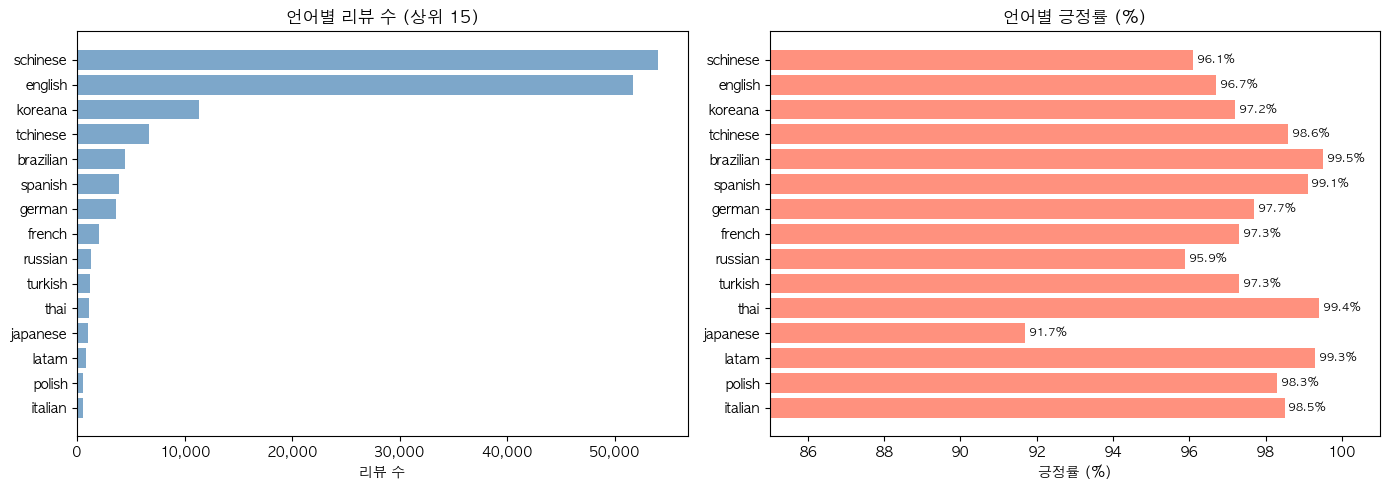

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(language['language'][::-1], language['total'][::-1], color='steelblue', alpha=0.7)
ax1.set_title('언어별 리뷰 수 (상위 15)')
ax1.set_xlabel('리뷰 수')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

ax2.barh(language['language'][::-1], language['positive_rate'][::-1], color='tomato', alpha=0.7)
ax2.set_title('언어별 긍정률 (%)')
ax2.set_xlabel('긍정률 (%)')
ax2.set_xlim(85, 101)
for i, val in enumerate(language['positive_rate'][::-1]):
    ax2.text(val + 0.1, i, f'{val}%', va='center', fontsize=8)

fig.tight_layout()
plt.savefig(os.path.join(figures_dir, 'language_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. 얼리액세스 vs 정식출시

얼리액세스 기간에 작성된 리뷰와 정식출시 이후 리뷰의
긍정률과 환불 비율을 비교한다.

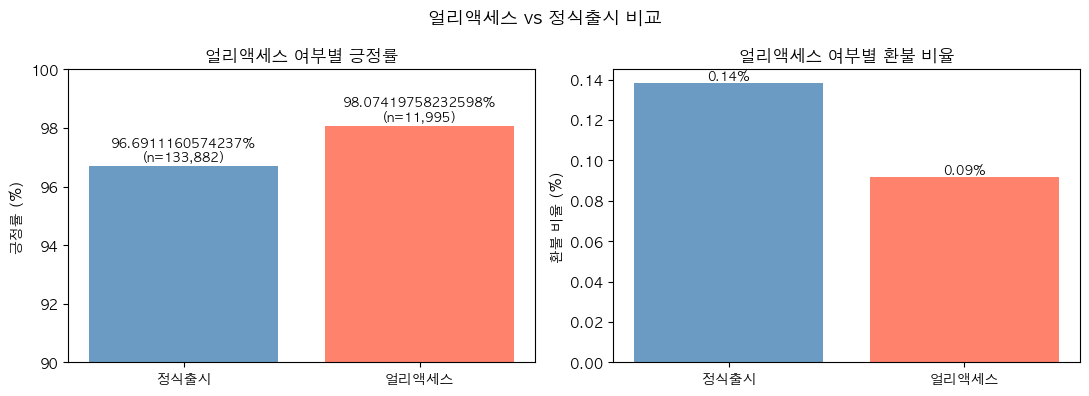

In [ ]:
early_stats = df.groupby('written_during_early_access').agg(
    count       = ('voted_up', 'count'),
    pos_rate    = ('voted_up', lambda x: x.mean() * 100),
    refund_rate = ('refunded', lambda x: x.mean() * 100)
).reset_index()
early_stats['label'] = early_stats['written_during_early_access'].map(
    {0: '정식출시', 1: '얼리액세스'}
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = ['steelblue', 'tomato']
ax1.bar(early_stats['label'], early_stats['pos_rate'], color=colors, alpha=0.8)
ax1.set_title('얼리액세스 여부별 긍정률')
ax1.set_ylabel('긍정률 (%)')
ax1.set_ylim(90, 100)
for i, (val, cnt) in enumerate(zip(early_stats['pos_rate'], early_stats['count'])):
    ax1.text(i, val + 0.1, f'{val}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=9)

ax2.bar(early_stats['label'], early_stats['refund_rate'], color=colors, alpha=0.8)
ax2.set_title('얼리액세스 여부별 환불 비율')
ax2.set_ylabel('환불 비율 (%)')
for i, val in enumerate(early_stats['refund_rate']):
    ax2.text(i, val + 0.001, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('얼리액세스 vs 정식출시 비교', fontsize=13)
fig.tight_layout()
plt.show()

---
## 8. Steam Deck 유저 분석

Steam Deck 주 사용 유저와 일반 PC 유저의
리뷰 수, 긍정률, 평균 플레이타임을 비교한다.

In [ ]:
deck = pd.read_sql("""
    SELECT
        primarily_steam_deck,
        COUNT(*) as count,
        ROUND(AVG(voted_up) * 100, 1) as positive_rate,
        ROUND(AVG(playtime_at_review / 60.0), 1) as avg_hours
    FROM reviews
    GROUP BY primarily_steam_deck
""", conn)

deck['label'] = deck['primarily_steam_deck'].map({0: 'PC', 1: 'Steam Deck'})
deck

,primarily_steam_deck,count,positive_rate,avg_hours,label
0,0,139649,96.9,27.4,PC
1,1,6228,95.1,23.9,Steam Deck


---
## 9. 환불 유저 분석

환불 여부 × 플레이타임 구간(0~30분, 30~60분, 60~90분, 90~120분)으로 나눠
각 구간의 리뷰 수와 긍정/부정 비율을 비교한다.
Steam 환불 정책(2시간 이내)에 따라 대부분이 2시간 이하 구간에 몰릴 것으로 예상된다.

In [ ]:
refund_df = df[df['playtime_at_review'].between(0, 120)].copy()

bins   = [0, 30, 60, 90, 120]
labels = ['0~30분', '30~60분', '60~90분', '90~120분']
refund_df['segment'] = pd.cut(refund_df['playtime_at_review'], bins=bins, labels=labels, right=True)

summary = refund_df.groupby(['refunded', 'segment', 'voted_up'], observed=True).size().unstack(fill_value=0)
summary.columns = ['부정', '긍정']
summary = summary.reset_index()
summary['segment'] = summary['segment'].astype(str)

table = summary.copy()
table['refunded'] = table['refunded'].map({0: '환불 안함', 1: '환불'})
table['total']    = table['긍정'] + table['부정']
table['긍정률(%)'] = (table['긍정'] / table['total'] * 100).round(1)
print(table[['refunded', 'segment', '긍정', '부정', 'total', '긍정률(%)']].to_string(index=False))

refunded segment   긍정  부정  total  긍정률(%)
   환불 안함   0~30분  986 216   1202    82.0
   환불 안함  30~60분 1018 138   1156    88.1
   환불 안함  60~90분 1142  87   1229    92.9
   환불 안함 90~120분 1163  78   1241    93.7
      환불   0~30분   26  33     59    44.1
      환불  30~60분   17  22     39    43.6
      환불  60~90분   17  22     39    43.6
      환불 90~120분   23  11     34    67.6


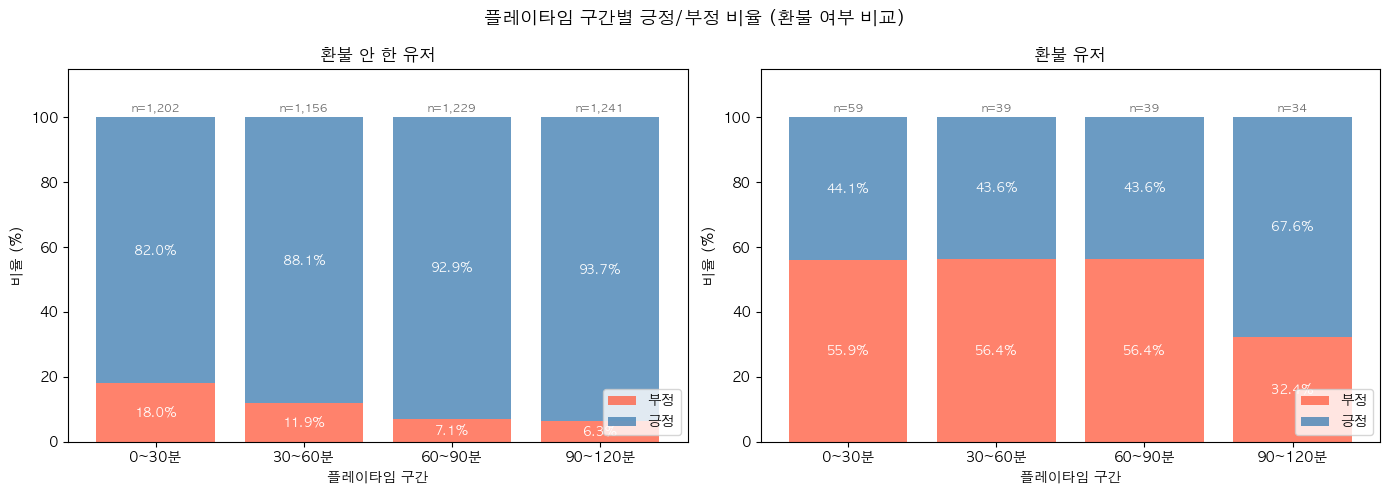

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = {0: '환불 안 한 유저', 1: '환불 유저'}

for ax, refund_val in zip(axes, [0, 1]):
    sub   = summary[summary['refunded'] == refund_val].set_index('segment')
    total = sub['긍정'] + sub['부정']
    pos_ratio = sub['긍정'] / total * 100
    neg_ratio = sub['부정'] / total * 100

    ax.bar(labels, neg_ratio, color='tomato',    alpha=0.8, label='부정')
    ax.bar(labels, pos_ratio, color='steelblue', alpha=0.8, label='긍정', bottom=neg_ratio)

    for i, (pos, neg, tot) in enumerate(zip(pos_ratio, neg_ratio, total)):
        if neg > 3:
            ax.text(i, neg / 2,       f'{neg:.1f}%', ha='center', va='center', fontsize=9, color='white')
        if pos > 3:
            ax.text(i, neg + pos / 2, f'{pos:.1f}%', ha='center', va='center', fontsize=9, color='white')
        ax.text(i, 101, f'n={tot:,}', ha='center', va='bottom', fontsize=8, color='dimgray')

    ax.set_title(titles[refund_val])
    ax.set_xlabel('플레이타임 구간')
    ax.set_ylabel('비율 (%)')
    ax.set_ylim(0, 115)
    ax.legend(loc='lower right')

fig.suptitle('플레이타임 구간별 긍정/부정 비율 (환불 여부 비교)', fontsize=13)
fig.tight_layout()
plt.show()

---
## 10. 리뷰 길이 × 긍정/부정 (언어별)

언어별 상위 6개를 뽑아, 각 언어에서 긍정/부정 리뷰의 글자 수 분포를 히스토그램으로 비교한다.
부정 리뷰가 더 길다면 불만을 상세히 서술하는 경향이 있다고 볼 수 있다.

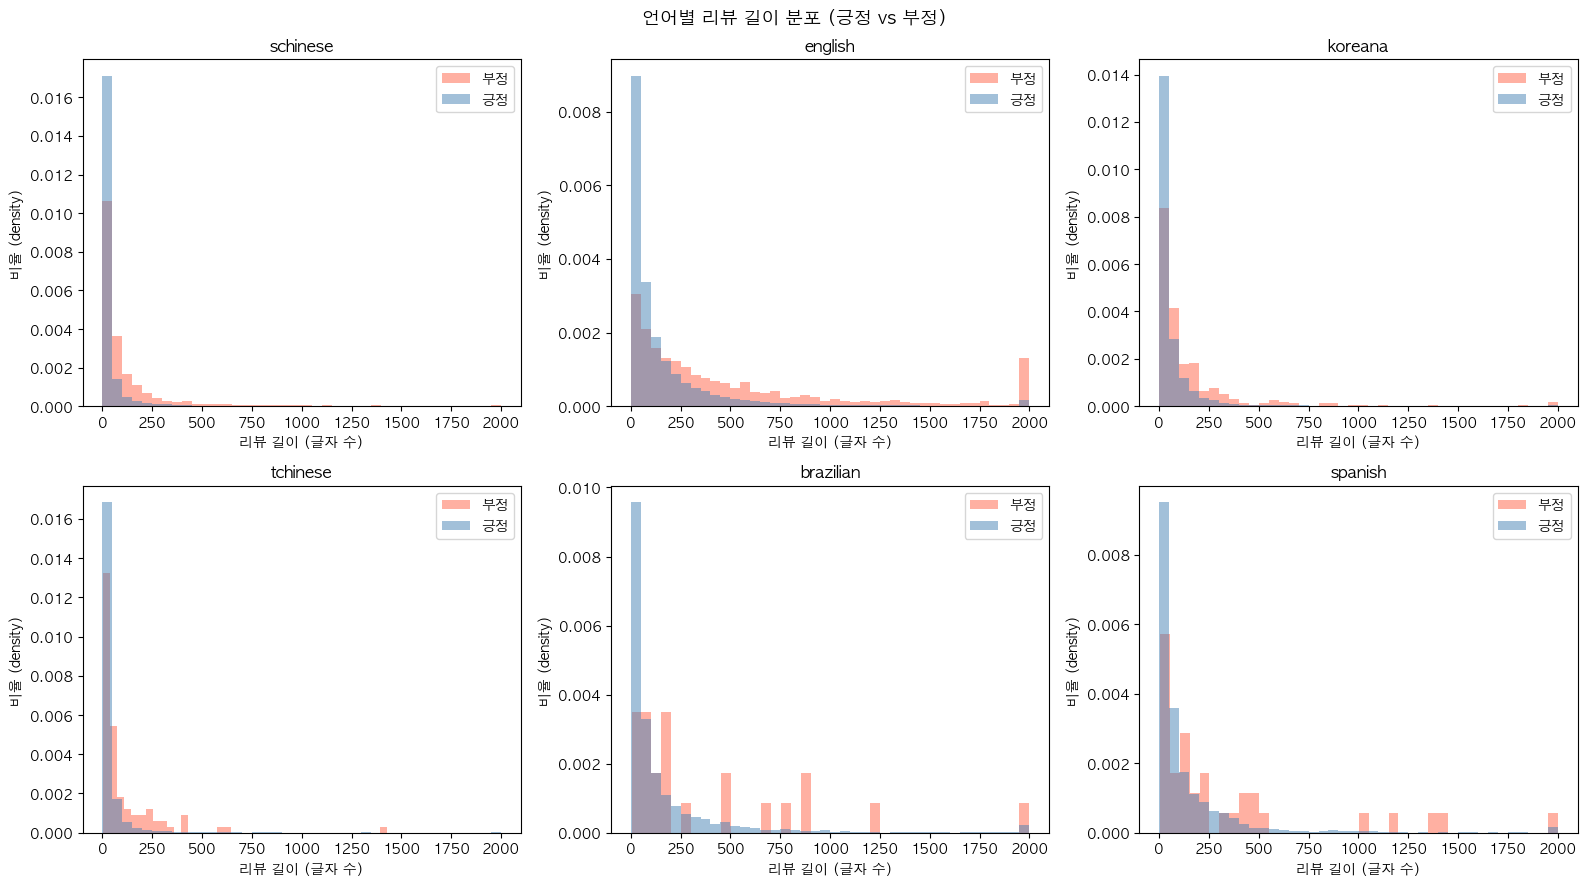

In [ ]:
top_langs = df['language'].value_counts().head(6).index
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, lang in zip(axes.flatten(), top_langs):
    sub = df[df['language'] == lang]
    for label, color, val in [('부정', 'tomato', 0), ('긍정', 'steelblue', 1)]:
        data = sub[sub['voted_up'] == val]['review_length'].clip(upper=2000)
        ax.hist(data, bins=40, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(lang)
    ax.set_xlabel('리뷰 길이 (글자 수)')
    ax.set_ylabel('비율 (density)')
    ax.legend()

fig.suptitle('언어별 리뷰 길이 분포 (긍정 vs 부정)', fontsize=13)
fig.tight_layout()
plt.show()

---
## 11. 유저 보유 게임 수 × 긍정률

스팀 라이브러리 크기로 유저를 6개 구간으로 나눠
구간별 리뷰 수와 긍정률을 확인한다.
게임 경험이 많은 유저일수록 평가 기준이 높아 긍정률이 낮아질 수 있다.

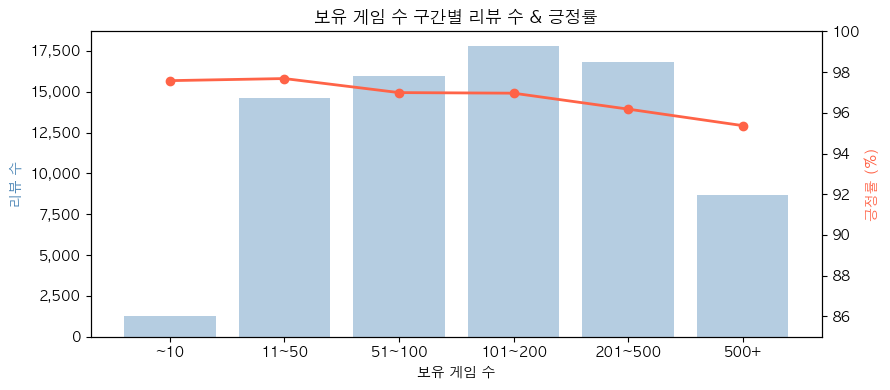

In [ ]:
bins   = [0, 10, 50, 100, 200, 500, 99999]
labels_g = ['~10', '11~50', '51~100', '101~200', '201~500', '500+']
df['game_segment'] = pd.cut(df['num_games_owned'], bins=bins, labels=labels_g)

game_stats = df.groupby('game_segment', observed=True).agg(
    count    = ('voted_up', 'count'),
    pos_rate = ('voted_up', lambda x: x.mean() * 100)
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(game_stats['game_segment'], game_stats['count'], color='steelblue', alpha=0.4)
ax1.set_ylabel('리뷰 수', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

ax2 = ax1.twinx()
ax2.plot(game_stats['game_segment'], game_stats['pos_rate'],
         color='tomato', marker='o', linewidth=2)
ax2.set_ylabel('긍정률 (%)', color='tomato')
ax2.set_ylim(85, 100)

ax1.set_title('보유 게임 수 구간별 리뷰 수 & 긍정률')
ax1.set_xlabel('보유 게임 수')
fig.tight_layout()
plt.show()

---
## 12. 요일/시간대별 리뷰 작성 패턴

UTC 기준 요일 × 시간대 히트맵으로 리뷰가 언제 많이 작성되는지 확인한다.
글로벌 유저가 많으므로 UTC 기준임에 유의한다.

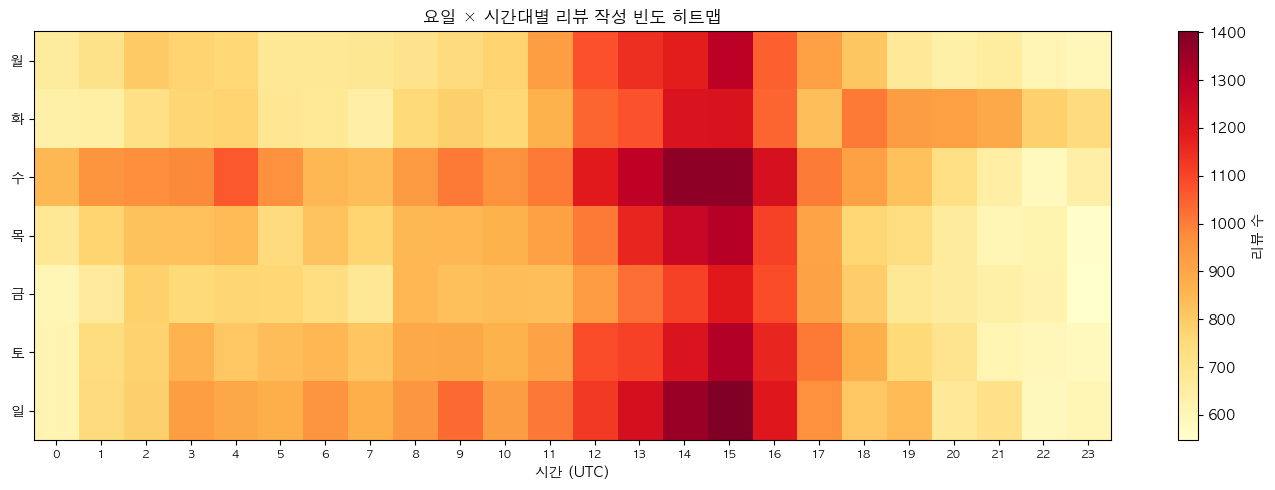

In [ ]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_kr    = ['월','화','수','목','금','토','일']

pivot = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels(weekday_kr)
ax.set_xlabel('시간 (UTC)')
ax.set_title('요일 × 시간대별 리뷰 작성 빈도 히트맵')
plt.colorbar(im, ax=ax, label='리뷰 수')
fig.tight_layout()
plt.show()

---
## 13. 부정 리뷰 중 추천 수 상위

다른 유저들이 '도움됨'을 누른 부정 리뷰 상위 20개를 확인한다.
많은 사람이 공감한 부정 리뷰는 실제 불만 사항의 대표성이 높다.
최대 추천 수가 10개 이하면 의미가 없으므로 생략한다.

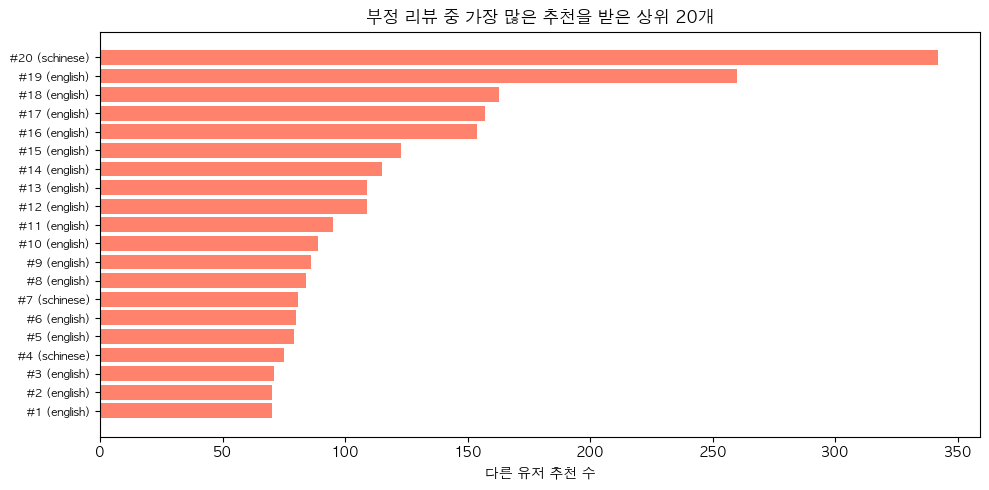


상위 10개 부정 리뷰 전문:

[#131574 | 추천 342개 | schinese | 2072자]
可惜steam没有中评，所以我还是比较纠结这个游戏该给好评还是差评的，但是最后综合考虑下来还是决定给差评
先说优点，我给这个游戏差评并不代表这个游戏不值得入手，入手还是值得的，因为游戏的其中一个优点就是量大管饱，而且初期的体验也确实是不错的。
在前期的时候，由于玩家的氧气上限很低，能潜的深度也不多，所以每一次的潜水流程都很短，在这种节奏下，较短的潜水时间搭配上同样快节奏的寿司时间，体验是相当好的，每天下去捞鱼，上岸后立马就能看到新捞上来的鱼能做什么菜能卖多少钱，这个时候的游戏体验的正反馈是相当好的，尤其是到了杀掉第一只三齿鲨拿鲨鱼头款待了第一位vip客户后解锁员工的这个阶段，游戏体验达到了高峰，但是这也正是整个游戏的体验的分水岭，从这个时间节点之后，整个游戏的游戏体验就开始渐渐下降了。
在这之后，随着玩家的潜水深度以及氧气量的提升，潜水的时长在游戏中的比重越来越大，是的，这的确是一款主打潜水捞鱼的游戏，潜水的比重更大也是应该的，但是糟糕的是驱动玩家去潜水捞鱼的动力，也就是捞新鱼、开新图、推剧情、拿新装备这几个推动力中只有捞新鱼这一点做的比较好，而且也只做好了一半，为什么这么说呢？
因为在游戏中，新的地图并没有什么有意思的新的地图机制来给玩家提供不一样的探索体验，甚至可以说是在起反作用，比如深海区域中需要用紫外线灯光驱散的虫，一点也不有趣，也不具备挑战性，反而是存粹的毁坏游戏的节奏，让人感到厌烦，是的，我们是可以在后面完成了鲛人村的任务后获得可以自动驱散虫子的项链，但是本来就只有两个宝贵的饰品栏位，一个栏位基本上得固定留给用来冲刺的那个饰品，另一个栏位就显得更加精贵了，再加上在潜水的中途也不能更换饰品，这使得我基本上不会选择佩戴这个首饰，因为哪怕抛开饰品栏位的稀缺，这个紫外线开虫子除了占用我的一个物品栏以外并没有给我带来什么操作上的麻烦，这便使得这一整个的机制都显得毫无意义，甚至让人恶心，而至于后面水库里无聊的解密和无趣的躲避邪恶鲛人的内容就比这更加糟糕了，鲛人村那页游既视感极强的跑腿任务更是个寄吧，因此玩家就是没有探索地图的乐趣，地图自然也就没有提供游戏进行下去的动力。
至于剧情方面，整个故事可以说是一个非常老掉牙的保护海洋环境以及向“原住民”赎罪，拯

In [ ]:
neg_helpful = df[df['voted_up'] == 0].nlargest(20, 'votes_up')[
    ['review_id', 'language', 'votes_up', 'review_length', 'review_text']
]

if neg_helpful['votes_up'].max() <= 10:
    print("최대 추천 수가 10개 이하 — 시각화 생략")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(neg_helpful)), neg_helpful['votes_up'][::-1], color='tomato', alpha=0.8)
    ax.set_yticks(range(len(neg_helpful)))
    ax.set_yticklabels(
        [f"#{i+1} ({row.language})" for i, row in enumerate(neg_helpful[::-1].itertuples())],
        fontsize=8
    )
    ax.set_xlabel('다른 유저 추천 수')
    ax.set_title('부정 리뷰 중 가장 많은 추천을 받은 상위 20개')
    fig.tight_layout()
    plt.show()

    print("\n상위 10개 부정 리뷰 전문:")
    for i, row in neg_helpful.head(10).iterrows():
        print(f"\n{'='*60}")
        print(f"[#{i+1} | 추천 {row.votes_up}개 | {row.language} | {row.review_length}자]")
        print(f"{'='*60}")
        print(row.review_text)

## 부정 리뷰 상위 10개 해석

---

### #1 | 추천 342개 | 중국어(간체) | 2072자

**한줄요약:** 스팀에 중립 평가가 없어서 억지로 부정을 골랐을 뿐, 게임 자체는 살 만하다.

초반(산소 짧고 잠수 얕은 구간)은 빠른 피드백 루프 덕분에 재밌다. 하지만 중반 이후 잠수 시간이 길어지면서 정작 재미있는 요소(양식·메뉴 해금)의 비중이 줄어들고, 탐험 동기 부족·진부한 스토리·빈약한 장비 시스템이 겹쳐 피로감이 쌓인다. "재미있는 구간이 점점 작아지는" 구조적 문제를 날카롭게 지적. 유비소프트식 "양은 많지만 깊이 없는 캔 게임"으로 결론.

> NLP 주의: 부정 리뷰지만 구매 추천 포함 → 감성 분류 시 노이즈 가능성

---

### #2 | 추천 260개 | 영어 | 345자

**한줄요약:** 아름답고 편안한 게임인데 QTE 연타가 신체 장애 유저에게 플레이를 불가능하게 만든다.

관절염·신경 손상·손목터널증후군이 있는 유저에게는 하포운 연타 QTE가 고통스럽거나 아예 플레이 불가. 결국 환불. 개발사가 접근성 옵션을 추가하면 돌아오겠다고 마무리. 민트로켓이 2023년 8월 QTE 스킵 기능을 추가한 직접적 원인으로 알려진 리뷰.

---

### #3 | 추천 163개 | 영어 | 4204자

**한줄요약:** 콘셉트와 비주얼은 훌륭하지만 10시간 이후 반복·노가다로 무너진다.

픽셀 아트와 식당 관리 파트(30%)는 칭찬. 하지만 잠수 파트(70%)는 조작감이 둔하고, 전투에 전략 요소가 없으며, 캐릭터들은 심부름 퀘스트만 던진다. 농장 마이크로관리는 플레이 시간 억지 늘리기용. 긍정 리뷰 대부분이 5~10시간만 플고 쓴 거라 과대평가됐다고 주장. 50시간 완주 후 작성.

---

### #4 | 추천 157개 | 영어 | 487자

**한줄요약:** 초반은 좋은데 중반부터 컷신·심부름·스텔스·마이크로관리로 가득 찬 다른 게임이 된다.

초반 몇 시간은 탐험과 장비 업그레이드로 즐겁다. 하지만 중반부터 끝없는 컷신, 심부름 퀘스트, 미니게임, 스텔스 구간, 시뮬레이션 요소가 쏟아지며 재미가 사라짐. 중립 평가를 주고 싶었지만 스팀 구조상 부정을 선택.

---

### #5 | 추천 154개 | 영어 | 5072자

**한줄요약:** 게임 리뷰가 아니라 넥슨·Unity·Backtrace의 무단 데이터 수집을 고발하는 프라이버시 리포트.

게임 내용 비판이 아닌 완전히 다른 맥락의 리뷰. Unity Analytics·Backtrace·Nexon API가 유저 동의 없이 SteamID·디바이스 정보·행동 데이터를 수집한다는 내용을 기술적으로 분석. MINTROCKET이 넥슨 자회사임을 숨겼다는 점도 지적. 차단 방법까지 제시.

> NLP 주의: 게임플레이 관련 텍스트가 거의 없어 토픽 모델링 시 노이즈 처리 권장

---

### #6 | 추천 123개 | 영어 | 749자

**한줄요약:** 초반엔 편안하지만 10시간 후 모바일 게임·MMO 잡일의 혼합물이 된다.

직접적으로 핵심만 말하는 구조. 시작은 좋지만 10시간 즈음부터 물고기 농장·작물 농장 등 단순 반복 작업이 쌓여 하루하루가 거대한 잡일이 된다. 다른 동류 게임들은 처음부터 본성이 드러나는 반면, 이 게임은 10~20시간을 빼앗은 뒤에야 본색을 드러낸다고 비판.

---

### #7 | 추천 115개 | 영어 | 890자

**한줄요약:** QTE 연타가 신체 장애 유저에게 고통스럽고, 1년 넘게 개발사가 묵묵부답이었다.

\#2 리뷰와 같은 접근성 문제. 포럼에 30페이지짜리 불만 스레드가 쌓였는데도 개발사가 오래 침묵했다는 점을 강조. 나중에 개발사가 수정 예정이라 답변했다는 Edit 추가. 실제로 추후 QTE 스킵 옵션이 추가됨.

---

### #8 | 추천 109개 | 영어 | 200자

**한줄요약:** 퍼블리셔가 넥슨임을 숨기고 있다는 이유만으로 부정 평가.

게임플레이 내용은 없음. 넥슨을 "그냥 악한 회사"로 규정하고, 넥슨 이름이 붙은 것은 모두 피하라고 권고. 넥슨이 자신들을 드러내지 않으려 한다고 주장.

> NLP 주의: 게임 내용과 무관한 기업 불매 리뷰

---

### #9 | 추천 109개 | 영어 | 182자

**한줄요약:** 개인정보처리방침 문구만 붙여넣고 "왜?"라고 묻는 풍자 리뷰.

실제 개인정보 수집 동의 문구를 그대로 붙여넣고 한 단어 "why?"로 마무리. \#5 리뷰와 같은 데이터 수집 우려를 극도로 압축한 형태. 간결함 덕분에 추천을 많이 받음.

> NLP 주의: 게임플레이 텍스트 없음, 노이즈 처리 권장

---

### #10 | 추천 95개 | 영어 | 219자

**한줄요약:** 넥슨 연관 사실을 스토어 페이지에서 숨겼다는 점이 불만.

게임 자체는 즐거웠다고 인정. 하지만 플레이 후에야 넥슨 자회사임을 알았고, 넥슨을 지지할 수 없어 부정 평가. 스토어 페이지에서 투명하게 공개했으면 좋겠다고 마무리.

> NLP 주의: \#8과 같은 기업 불매 리뷰, 게임 내용과 무관

---

## 종합 패턴 메모

- **접근성 문제 (QTE 연타):** \#2, \#7 → 민트로켓이 실제로 수정한 이슈
- **후반부 반복·노가다:** \#1, \#3, \#4, \#6 → 가장 많은 부정 리뷰의 핵심 원인
- **넥슨·프라이버시 이슈:** \#5, \#8, \#9, \#10 → 게임플레이와 무관, NLP 노이즈 처리 필요
- **중립 평가 없는 스팀 구조 불만:** \#1, \#4 → 실질적으로는 긍정에 가까운 리뷰

---
## 14. 리뷰 수정 유저 분석

timestamp_updated > timestamp_created인 경우를 수정 리뷰로 정의한다.
수정 여부별 긍정률, 수정까지 걸린 시간 분포, 수정 시점 구간별 긍정률을 확인한다.
수정 시점이 길수록 감성이 변화했을 가능성이 있다.

수정한 유저     : 11,440건 (7.8%)
수정 안 한 유저 : 134,437건


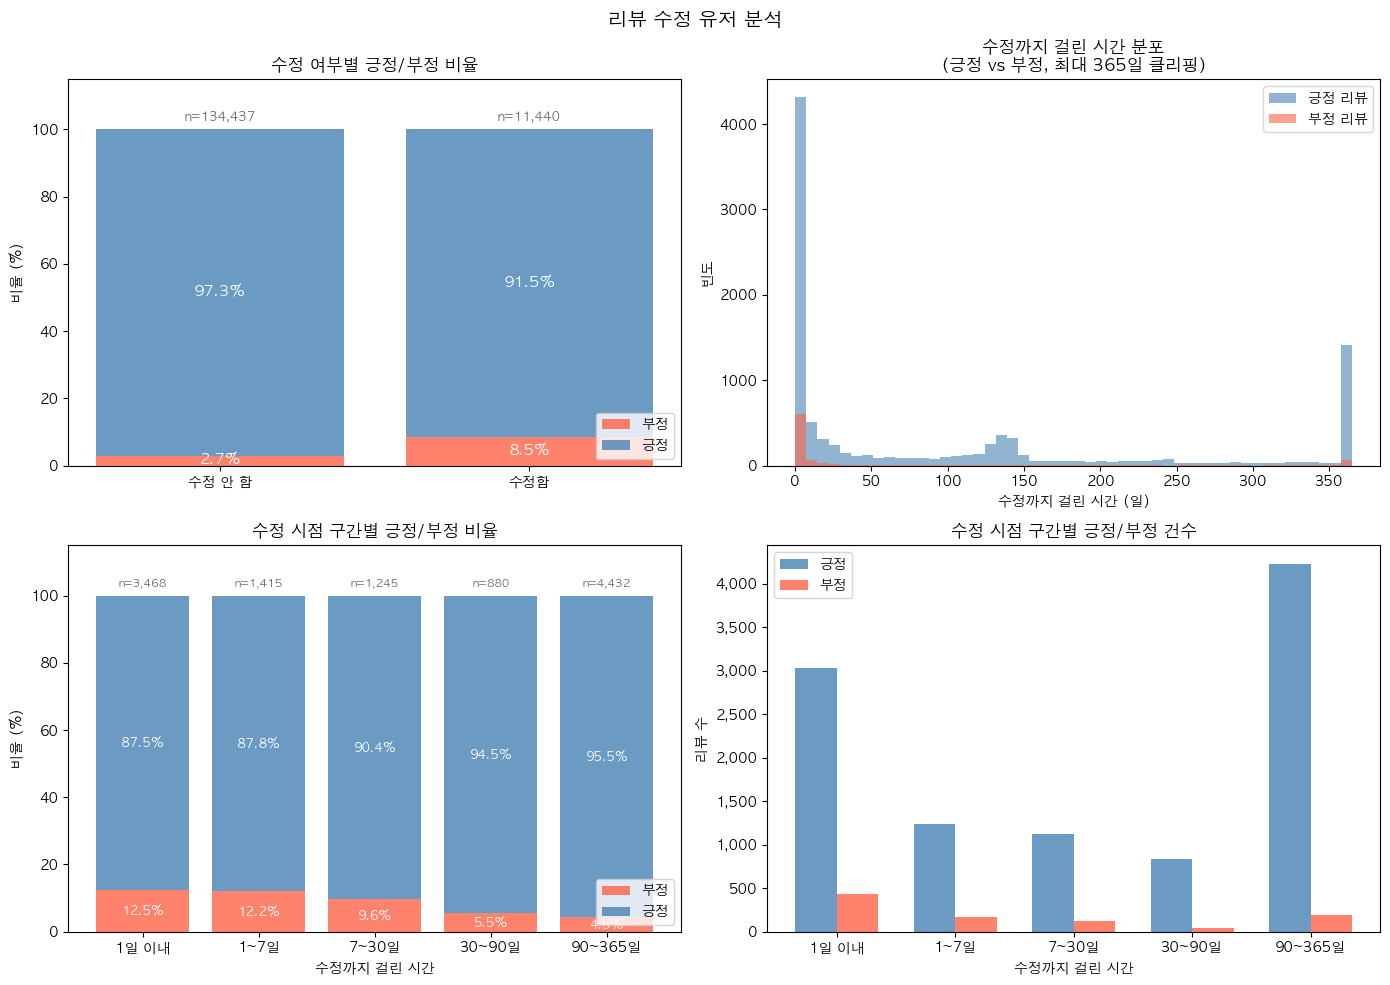

In [ ]:
updated     = df[df['timestamp_updated'] > df['timestamp_created']].copy()
not_updated = df[df['timestamp_updated'] == df['timestamp_created']].copy()

updated['update_lag_days'] = (
    (updated['timestamp_updated'] - updated['timestamp_created']) / 86400
).clip(upper=365)

lag_bins   = [0, 1, 7, 30, 90, 365]
lag_labels = ['1일 이내', '1~7일', '7~30일', '30~90일', '90~365일']
updated['lag_segment'] = pd.cut(updated['update_lag_days'], bins=lag_bins, labels=lag_labels)

print(f"수정한 유저     : {len(updated):,}건 ({len(updated)/len(df)*100:.1f}%)")
print(f"수정 안 한 유저 : {len(not_updated):,}건")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 1. 수정 여부별 긍정/부정 스택 바 ──────────────────────────────────────
groups = {
    '수정 안 함': not_updated,
    '수정함':     updated,
}
labels_g, pos_rates, neg_rates, counts = [], [], [], []
for label, grp in groups.items():
    total = len(grp)
    pos   = grp['voted_up'].mean() * 100
    neg   = 100 - pos
    labels_g.append(label)
    pos_rates.append(pos)
    neg_rates.append(neg)
    counts.append(total)

bars_neg = axes[0, 0].bar(labels_g, neg_rates, color='tomato',    alpha=0.8, label='부정')
bars_pos = axes[0, 0].bar(labels_g, pos_rates, color='steelblue', alpha=0.8, label='긍정',
                           bottom=neg_rates)

for i, (pos, neg, n) in enumerate(zip(pos_rates, neg_rates, counts)):
    if neg > 2:
        axes[0, 0].text(i, neg / 2,       f'{neg:.1f}%', ha='center', va='center',
                        fontsize=11, color='white', fontweight='bold')
    axes[0, 0].text(i, neg + pos / 2, f'{pos:.1f}%', ha='center', va='center',
                    fontsize=11, color='white', fontweight='bold')
    axes[0, 0].text(i, 102, f'n={n:,}', ha='center', va='bottom', fontsize=9, color='dimgray')

axes[0, 0].set_ylim(0, 115)
axes[0, 0].set_ylabel('비율 (%)')
axes[0, 0].set_title('수정 여부별 긍정/부정 비율')
axes[0, 0].legend(loc='lower right')

# ── 2. 수정까지 걸린 시간 분포 히스토그램 ────────────────────────────────
axes[0, 1].hist(updated[updated['voted_up'] == 1]['update_lag_days'],
                bins=50, color='steelblue', alpha=0.6, label='긍정 리뷰')
axes[0, 1].hist(updated[updated['voted_up'] == 0]['update_lag_days'],
                bins=50, color='tomato',    alpha=0.6, label='부정 리뷰')
axes[0, 1].set_xlabel('수정까지 걸린 시간 (일)')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].set_title('수정까지 걸린 시간 분포\n(긍정 vs 부정, 최대 365일 클리핑)')
axes[0, 1].legend()

# ── 3. 수정 시점 구간별 긍정/부정 스택 바 ────────────────────────────────
lag_stats = updated.groupby('lag_segment', observed=True).agg(
    count    = ('voted_up', 'count'),
    pos_cnt  = ('voted_up', 'sum'),
).reset_index()
lag_stats['neg_cnt']  = lag_stats['count'] - lag_stats['pos_cnt']
lag_stats['pos_rate'] = lag_stats['pos_cnt'] / lag_stats['count'] * 100
lag_stats['neg_rate'] = lag_stats['neg_cnt'] / lag_stats['count'] * 100

x = range(len(lag_stats))
axes[1, 0].bar(x, lag_stats['neg_rate'], color='tomato',    alpha=0.8, label='부정')
axes[1, 0].bar(x, lag_stats['pos_rate'], color='steelblue', alpha=0.8, label='긍정',
               bottom=lag_stats['neg_rate'])

for i, row in lag_stats.iterrows():
    if row['neg_rate'] > 2:
        axes[1, 0].text(i, row['neg_rate'] / 2,
                        f"{row['neg_rate']:.1f}%", ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
    axes[1, 0].text(i, row['neg_rate'] + row['pos_rate'] / 2,
                    f"{row['pos_rate']:.1f}%", ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    axes[1, 0].text(i, 102, f"n={row['count']:,}", ha='center', va='bottom',
                    fontsize=8, color='dimgray')

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(lag_stats['lag_segment'])
axes[1, 0].set_ylim(0, 115)
axes[1, 0].set_ylabel('비율 (%)')
axes[1, 0].set_xlabel('수정까지 걸린 시간')
axes[1, 0].set_title('수정 시점 구간별 긍정/부정 비율')
axes[1, 0].legend(loc='lower right')

# ── 4. 수정 시점 구간별 실제 건수 (긍정/부정 분리) ───────────────────────
w = 0.35
xi = list(range(len(lag_stats)))
axes[1, 1].bar([i - w/2 for i in xi], lag_stats['pos_cnt'],
               width=w, color='steelblue', alpha=0.8, label='긍정')
axes[1, 1].bar([i + w/2 for i in xi], lag_stats['neg_cnt'],
               width=w, color='tomato',    alpha=0.8, label='부정')

axes[1, 1].set_xticks(xi)
axes[1, 1].set_xticklabels(lag_stats['lag_segment'])
axes[1, 1].set_ylabel('리뷰 수')
axes[1, 1].set_xlabel('수정까지 걸린 시간')
axes[1, 1].set_title('수정 시점 구간별 긍정/부정 건수')
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
axes[1, 1].legend()

fig.suptitle('리뷰 수정 유저 분석', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(os.path.join(figures_dir, 'review_update_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 15. 개발자 응답 리뷰 분석

개발자가 응답을 남긴 리뷰를 분리해 분석한다.
응답이 달린 리뷰는 주로 불만 리뷰이므로 긍정률이 낮을 것으로 예상된다.
월별 응답 추이와 언어 분포도 함께 확인한다.
데이터가 10건 이하면 희소 데이터로 판단해 시각화를 생략한다.

개발자 응답 있음: 1,320건 (0.9%)


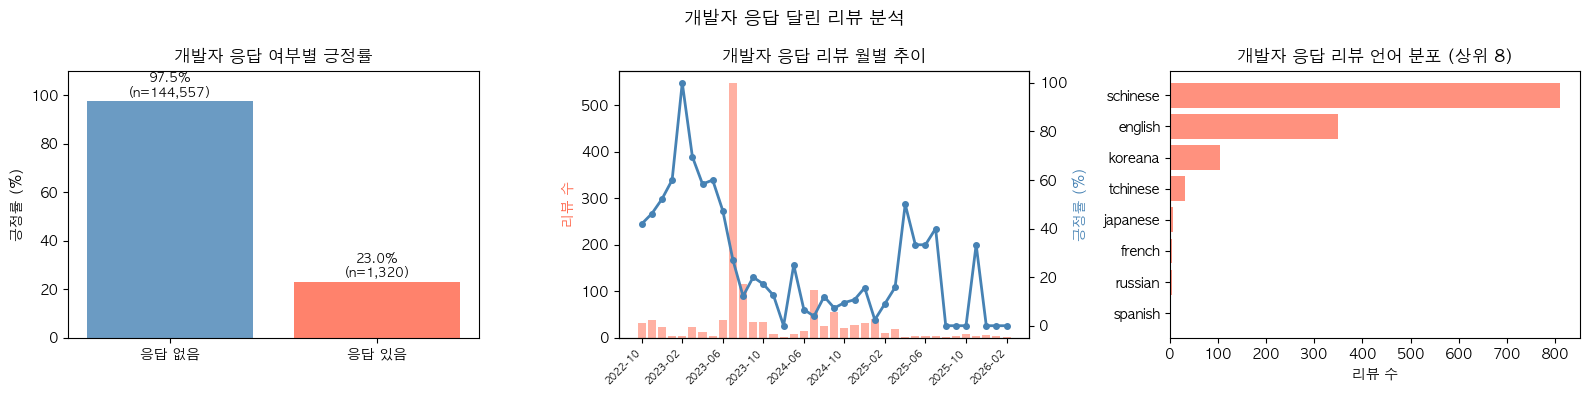

In [ ]:
dev_resp    = df[df['developer_response'].notna() & (df['developer_response'] != '')].copy()
no_dev_resp = df[df['developer_response'].isna()  | (df['developer_response'] == '')].copy()

print(f"개발자 응답 있음: {len(dev_resp):,}건 ({len(dev_resp)/len(df)*100:.1f}%)")

if len(dev_resp) <= 10:
    print("개발자 응답 리뷰 수가 너무 적어 시각화 생략")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    resp_pos    = dev_resp['voted_up'].mean() * 100
    no_resp_pos = no_dev_resp['voted_up'].mean() * 100

    bars = axes[0].bar(
        ['응답 없음', '응답 있음'],
        [no_resp_pos, resp_pos],
        color=['steelblue', 'tomato'], alpha=0.8
    )
    axes[0].set_ylim(0, 110)
    axes[0].set_ylabel('긍정률 (%)')
    axes[0].set_title('개발자 응답 여부별 긍정률')
    for bar, val, n in zip(bars, [no_resp_pos, resp_pos], [len(no_dev_resp), len(dev_resp)]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1,
                     f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)

    monthly_dev = dev_resp.groupby('review_month').agg(
        count    = ('voted_up', 'count'),
        pos_rate = ('voted_up', lambda x: x.mean() * 100)
    ).reset_index()

    ax_r = axes[1].twinx()
    axes[1].bar(range(len(monthly_dev)), monthly_dev['count'], color='tomato', alpha=0.5)
    ax_r.plot(range(len(monthly_dev)), monthly_dev['pos_rate'],
              color='steelblue', marker='o', linewidth=2, markersize=4)

    step = max(1, len(monthly_dev) // 8)
    axes[1].set_xticks(range(0, len(monthly_dev), step))
    axes[1].set_xticklabels(monthly_dev['review_month'].iloc[::step], rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('리뷰 수', color='tomato')
    ax_r.set_ylabel('긍정률 (%)', color='steelblue')
    axes[1].set_title('개발자 응답 리뷰 월별 추이')

    lang_dist = dev_resp['language'].value_counts().head(8)
    axes[2].barh(lang_dist.index[::-1], lang_dist.values[::-1], color='tomato', alpha=0.7)
    axes[2].set_xlabel('리뷰 수')
    axes[2].set_title('개발자 응답 리뷰 언어 분포 (상위 8)')
    axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

    fig.suptitle('개발자 응답 달린 리뷰 분석', fontsize=13)
    fig.tight_layout()
    plt.show()

---

## 16. 보유 게임 수 구간 × 플레이타임 5구간

"스팀 라이브러리 크기와 플레이타임 사이에 어떤 관계가 있는가"를 양방향으로 본 그래프

비공개 프로필 제외 전: 145,877건
비공개 프로필 제외 후: 75,161건 (70,716건 제외)


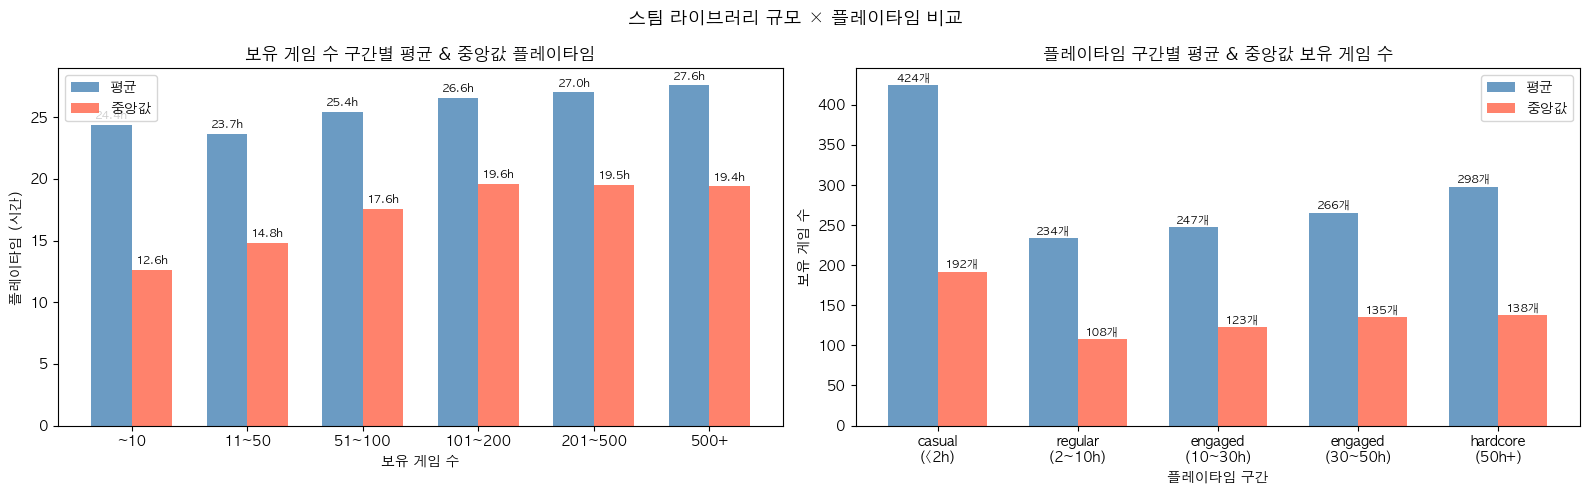

In [ ]:
# num_games_owned = 0은 비공개 프로필로 간주해 제외
df_games = df[df['num_games_owned'] > 0].copy()
print(f"비공개 프로필 제외 전: {len(df):,}건")
print(f"비공개 프로필 제외 후: {len(df_games):,}건 ({(df['num_games_owned'] == 0).sum():,}건 제외)")

bins_g   = [0, 10, 50, 100, 200, 500, 99999]
labels_g = ['~10', '11~50', '51~100', '101~200', '201~500', '500+']

bins_p   = [0, 120, 600, 1800, 3000, 999999]
labels_p = ['casual\n(<2h)', 'regular\n(2~10h)', 'engaged\n(10~30h)', 'engaged\n(30~50h)', 'hardcore\n(50h+)']

df['game_segment'] = pd.cut(df['num_games_owned'],    bins=bins_g, labels=labels_g)
df['play_segment'] = pd.cut(df['playtime_at_review'], bins=bins_p, labels=labels_p)

# 집계
game_play = df.groupby('game_segment', observed=True).agg(
    count           = ('voted_up', 'count'),
    avg_playtime    = ('playtime_hours_at_review', 'mean'),
    median_playtime = ('playtime_hours_at_review', 'median'),
).reset_index()

play_game = df[df['num_games_owned'] > 0].groupby('play_segment', observed=True).agg(
    avg_games    = ('num_games_owned', 'mean'),
    median_games = ('num_games_owned', 'median'),
    count        = ('num_games_owned', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 1. 보유 게임 수 구간별 평균 & 중앙값 플레이타임 ──
x = range(len(game_play))
w = 0.35
axes[0].bar([i - w/2 for i in x], game_play['avg_playtime'],
            width=w, color='steelblue', alpha=0.8, label='평균')
axes[0].bar([i + w/2 for i in x], game_play['median_playtime'],
            width=w, color='tomato', alpha=0.8, label='중앙값')

for i, row in game_play.iterrows():
    axes[0].text(i - w/2, row['avg_playtime'] + 0.3,
                 f"{row['avg_playtime']:.1f}h", ha='center', va='bottom', fontsize=8)
    axes[0].text(i + w/2, row['median_playtime'] + 0.3,
                 f"{row['median_playtime']:.1f}h", ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_g)
axes[0].set_xlabel('보유 게임 수')
axes[0].set_ylabel('플레이타임 (시간)')
axes[0].set_title('보유 게임 수 구간별 평균 & 중앙값 플레이타임')
axes[0].legend()

# ── 2. 플레이타임 5구간별 보유 게임 수 평균 & 중앙값 ──
x2 = range(len(play_game))
axes[1].bar([i - w/2 for i in x2], play_game['avg_games'],
            width=w, color='steelblue', alpha=0.8, label='평균')
axes[1].bar([i + w/2 for i in x2], play_game['median_games'],
            width=w, color='tomato', alpha=0.8, label='중앙값')

for i, row in play_game.iterrows():
    axes[1].text(i - w/2, row['avg_games'] + 2,
                 f"{row['avg_games']:.0f}개", ha='center', va='bottom', fontsize=8)
    axes[1].text(i + w/2, row['median_games'] + 2,
                 f"{row['median_games']:.0f}개", ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels_p)
axes[1].set_xlabel('플레이타임 구간')
axes[1].set_ylabel('보유 게임 수')
axes[1].set_title('플레이타임 구간별 평균 & 중앙값 보유 게임 수')
axes[1].legend()

fig.suptitle('스팀 라이브러리 규모 × 플레이타임 비교', fontsize=13)
fig.tight_layout()
plt.show()

---
## 17. DB 연결 종료

In [ ]:
conn.close()
print("EDA 완료. 다음 단계: 03_nlp_preprocessing.ipynb")

EDA 완료. 다음 단계: 03_nlp_preprocessing.ipynb
